In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('Delhi.csv')

In [4]:
print(df.head())

      Price  Area          Location  No. of Bedrooms  Resale  \
0  10500000  1200  Sector 10 Dwarka                2       1   
1   6000000  1000       Uttam Nagar                3       0   
2  15000000  1350      Sarita Vihar                2       1   
3   2500000   435       Uttam Nagar                2       0   
4   5800000   900        Dwarka Mor                3       0   

   MaintenanceStaff  Gymnasium  SwimmingPool  LandscapedGardens  JoggingTrack  \
0                 0          1             0                  0             1   
1                 0          0             0                  0             0   
2                 0          0             0                  0             0   
3                 0          0             0                  0             0   
4                 0          0             0                  0             0   

   ...  LiftAvailable  BED  VaastuCompliant  Microwave  GolfCourse  TV  \
0  ...              1    0                1          0

In [5]:
print(df.shape)

(4998, 40)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                4998 non-null   int64 
 1   Area                 4998 non-null   int64 
 2   Location             4998 non-null   object
 3   No. of Bedrooms      4998 non-null   int64 
 4   Resale               4998 non-null   int64 
 5   MaintenanceStaff     4998 non-null   int64 
 6   Gymnasium            4998 non-null   int64 
 7   SwimmingPool         4998 non-null   int64 
 8   LandscapedGardens    4998 non-null   int64 
 9   JoggingTrack         4998 non-null   int64 
 10  RainWaterHarvesting  4998 non-null   int64 
 11  IndoorGames          4998 non-null   int64 
 12  ShoppingMall         4998 non-null   int64 
 13  Intercom             4998 non-null   int64 
 14  SportsFacility       4998 non-null   int64 
 15  ATM                  4998 non-null   int64 
 16  ClubHo

In [8]:
print(df.describe())

              Price          Area  No. of Bedrooms      Resale  \
count  4.998000e+03   4998.000000      4998.000000  4998.00000   
mean   1.588638e+07   1277.343737         2.657863     0.80012   
std    4.612894e+07    915.217800         0.820605     0.39995   
min    2.000000e+06    200.000000         1.000000     0.00000   
25%    2.900000e+06    800.000000         2.000000     1.00000   
50%    5.500000e+06   1000.000000         3.000000     1.00000   
75%    1.580000e+07   1650.000000         3.000000     1.00000   
max    8.546000e+08  16000.000000         8.000000     1.00000   

       MaintenanceStaff    Gymnasium  SwimmingPool  LandscapedGardens  \
count       4998.000000  4998.000000   4998.000000        4998.000000   
mean           5.423770     5.472589      5.415966           5.435574   
std            4.378355     4.322819      4.387116           4.365041   
min            0.000000     0.000000      0.000000           0.000000   
25%            0.000000     0.000000    

In [7]:
print(df.isnull().sum())

Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0
Stadium                0


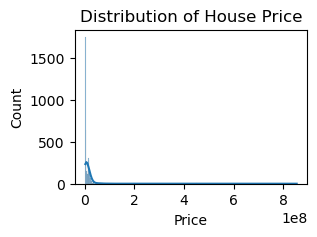

In [10]:
plt.figure(figsize=(3,2))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of House Price')
plt.show()

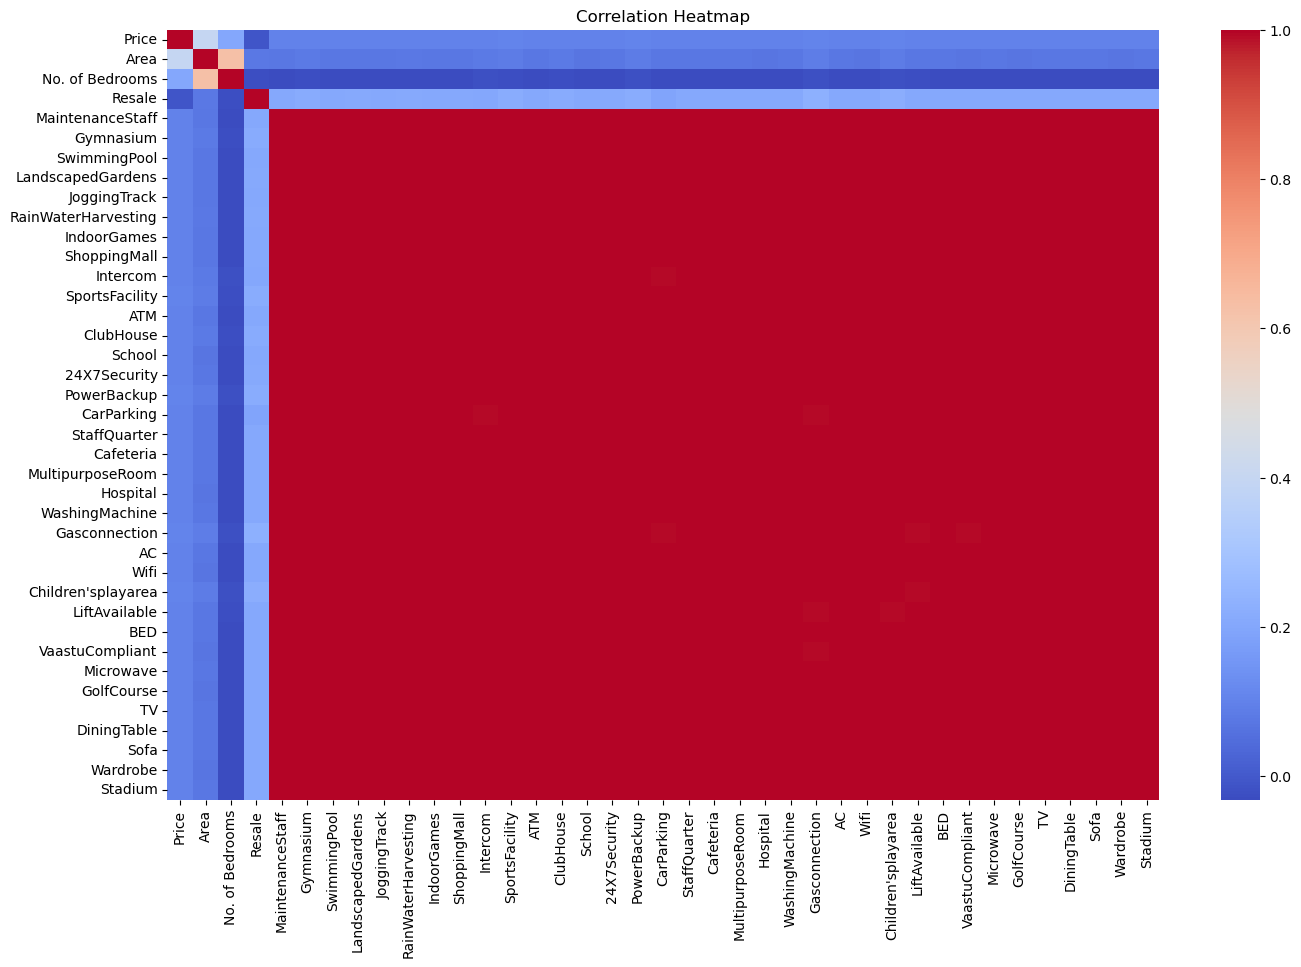

In [11]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [13]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [14]:
X = df.drop('Price', axis=1)
y = df['Price']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

1. Simple Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
X_simple = df[['Area']]
y_simple = df['Price']

In [19]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

In [21]:
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

LinearRegression()

In [22]:
simple_pred = simple_model.predict(X_test_s)

In [23]:
print('Simple Linear Regression')
print('R2 Score:', r2_score(y_test_s, simple_pred))
print('MAE:', mean_absolute_error(y_test_s, simple_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test_s, simple_pred)))

Simple Linear Regression
R2 Score: 0.06844875132775097
MAE: 12797908.296882844
RMSE: 38563794.38110011
